# Hubbard model with FNQS
---

This tutorial shows how to extend the Foundation NQS framework to **fermionic systems**. We
train a single network $\psi(\sigma; U)$ simultaneously over a family of
1D Hubbard Hamiltonians parameterised by the on-site interaction $U$.
The fermionic operators `create`, `destroy`, and `number` from
{mod}`netket_foundation.operator` are used to build the Hamiltonian, and
a backflow–Jastrow ansatz replaces the spin ViT used in Tutorial 1.

This tutorial covers:

1. Building the Hubbard Hamiltonian with {func}`~netket_foundation.operator.create`, {func}`~netket_foundation.operator.destroy`, {func}`~netket_foundation.operator.number`
2. Constructing a fermionic FNQS with a ViT backflow and a multiplicative Jastrow factor
3. Training with {class}`~netket_foundation.VMC_NG` across the full $U$ range in one run
4. Comparing the resulting ground-state energies to exact diagonalisation
5. Quantum Fisher information $\chi(U)$ via importance-sampling reweighting

For the spin-system FNQS workflow see **[Tutorial 1 – FNQS training basics](1.%20FNQS%20training%20basics.ipynb)**.
For the IS theory and the ESS diagnostic see **[Tutorial 3 – Importance Sampling](3.%20Importance%20Sampling.ipynb)**.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")

import time
import numpy as np
import jax.numpy as jnp
import flax.linen as nn
import matplotlib.pyplot as plt
import optax

import netket as nk
import netket_foundation as nkf
from netket_foundation.expectation_value import ISState
from netket_foundation.observable import SusceptibilityObservable

from netket_foundation.operator import create as fcdag
from netket_foundation.operator import destroy as fc
from netket_foundation.operator import number as fnc

from netket_foundation._src.model.fermionic_model.fermi_vit.body import foundation_ViT_trans_equi
from netket_foundation._src.model.fermionic_model.fermi_backflow import foundation_backflow
from netket_foundation._src.model.fermionic_model.fermi_jastrow import foundation_fermi_Jastrow_MLP
from netket_foundation._src.model.fermionic_model.activation import log_cosh
from netket_foundation._src.model.fermionic_model.prod_module import ProductModule
from netket_foundation._src.model.fermionic_model.ED_calculation import exact_ground_state_energy

∣NK⟩ Tip: HDF5Log/MLFlowLog/TensorBoardLog accept metadata={'L': 20, 'model': 'RBM'} to store hyperparameters with

the run.

## System: 1D Hubbard chain
---

$$
\hat H(U) = -t \sum_{\langle i,j\rangle,\sigma}
\bigl(c^\dagger_{i\sigma} c_{j\sigma} + \mathrm{h.c.}\bigr)
+ U \sum_i n_{i\uparrow}\, n_{i\downarrow},
$$

with $L = 8$ sites, periodic boundary conditions, $t = 1$, half-filling
($N_\uparrow = N_\downarrow = 4$), and $U \in [0, 4]$.
At $U = 0$ the system is a free Fermi gas; as $U$ grows correlations build up
and the Mott insulating regime is approached.

The Hubbard Hamiltonian is built using the second-quantisation operators
from `netket_foundation.operator`.  The spin projections are encoded as
$\uparrow \equiv +1$ and $\downarrow \equiv -1$.

In [2]:
L         = 8
N_fermions = L // 2          # half-filling: 2 electrons per spin sector
graph      = nk.graph.Chain(L, pbc=True)
hi         = nk.hilbert.SpinOrbitalFermions(
    L, s=1/2, n_fermions_per_spin=(N_fermions, N_fermions)
)

ps = nkf.ParameterSpace(N=1, min=0.0, max=4.0)

up, down   = +1, -1
bonds_nn   = [tuple(e) for e in graph.edges()]

def create_operator(params):
    assert params.shape == (1,)
    U = params[0]
    t = 1.0
    H_t = sum(
        (
            fcdag(hi, i, spin) @ fc(hi, j, spin)
            + fcdag(hi, j, spin) @ fc(hi, i, spin)
        )
        for i, j in bonds_nn
        for spin in (up, down)
    )
    H_U = sum(fnc(hi, i, up) @ fnc(hi, i, down) for i in range(L))
    return -t * H_t.to_jax_operator() + U * H_U.to_jax_operator()

ha_p = nkf.operator.ParametrizedOperator(hi, ps, create_operator)

print(f"Hilbert space: {hi}")
print(f"Number of basis states: {hi.n_states}")
print(f"U in [{ps._min}, {ps._max}]")

Hilbert space: SpinOrbitalFermions(n_orbitals=8, s=1/2, n_fermions=8, n_fermions_per_spin=(4, 4))
Number of basis states: 4900
U in [0.0, 4.0]


## Fermionic FNQS architecture
---

Spin systems use a plain ViT that maps occupation strings to log-amplitudes.
For fermions the ansatz must encode the correct antisymmetry.
We use a **backflow + Jastrow** architecture:

- **ViT trunk** — a translation-equivariant Vision Transformer that processes
  the occupation string (and the coupling $U$) into per-orbital features.
- **Backflow** — wraps the ViT to produce the matrix elements of a
  (generalised) Slater determinant, giving the correct fermionic sign structure.
- **Jastrow MLP** — a multiplicative correlator on top of the determinant
  that captures density–density correlations missed by the mean-field picture.

The full wavefunction is $\psi = \psi_{\mathrm{Jastrow}} \times \psi_{\mathrm{backflow}}$,
assembled by `ProductModule`.
Both sub-networks receive $U$ as an extra input through the shared
{class}`~netket_foundation.ParameterSpace`, so a single set of weights
covers the entire $U$ range.

In [3]:
pars_type  = jnp.float64
seed       = 42

# ViT hyper-parameters
n_layers   = 2
d_latent   = 16
heads      = 2
b          = 2                           # patch size
n_patches  = L // b
d_output   = hi.n_orbitals * hi.n_fermions

vit = foundation_ViT_trans_equi(
    n_layers=n_layers, d_model=d_latent, d_output=d_output, d_latent=d_latent,
    heads=heads, b=b, is_2d=False, n_patches=n_patches, n_coups=ps.size,
    graph=graph, out_activation=nn.tanh, param_dtype=pars_type,
)
backflow = foundation_backflow(
    model=vit, hilbert=hi, graph=graph, param_dtype=pars_type
)
jastrow = foundation_fermi_Jastrow_MLP(
    n_layers=n_layers, n_coups=ps.size, d_model=d_latent,
    initializer=nn.initializers.lecun_normal(),
    param_dtype=pars_type, out_activation=log_cosh,
)
ma = ProductModule(jastrow, backflow)

# Replicas uniformly spaced across U ∈ [0, 4]
n_replicas       = 16
parameter_array  = jnp.linspace(0.0, 4.0, n_replicas, dtype=pars_type).reshape(-1, 1)

sa = nk.sampler.MetropolisFermionHop(
    hilbert=hi, n_chains=n_replicas, graph=graph, sweep_size=hi.size
)
vs = nkf.FoundationalQuantumState(
    sa, ma, ps, n_replicas=n_replicas, seed=seed, n_samples=n_replicas * 32
)
vs.parameter_array = parameter_array

print(f"Parameters: {vs.n_parameters}")
print(f"Replicas:   {vs.n_replicas},  samples: {vs.n_samples}")

Parameters: 5520
Replicas:   16,  samples: 512


## Training
---

{class}`~netket_foundation.VMC_NG` drives all replicas simultaneously.
We pass `use_ntk=True` to compute the natural gradient via the Neural
Tangent Kernel.
The learning rate follows a linear decay and the diagonal shift
decays exponentially to allow fine convergence in the final iterations.

In [4]:
epochs        = 512
optimizer     = optax.sgd(learning_rate=optax.linear_schedule(init_value=0.05, end_value=0.005, transition_steps=epochs))
diag_shift    = optax.exponential_decay(1e-2, end_value=1e-4, transition_steps=32, decay_rate=0.8)

gs = nkf.VMC_NG(
    ha_p,
    optimizer,
    variational_state=vs,
    diag_shift=diag_shift,
    use_ntk=True,
    linear_solver = nk.optimizer.solver.pinv_smooth(rtol=1e-8, rtol_smooth=1e-8)
)

t0 = time.perf_counter()
gs.run(epochs, show_progress=True)
print(f"Training done in {time.perf_counter() - t0:.0f} s")

online_statistics: chain_length=32, exponential moving average window: 50, decay=0.500


  0%|                                                                                                         …

Training done in 165 s


## Post-training evaluation
---

After training, `vs.get_state(params)` extracts a standard
{class}`netket.vqs.MCState` pinned to a specific $U$ value.
We sweep over the full $U$ grid, measure the energy, and compare
it to exact diagonalisation (ED).
Because the Hilbert space is small ($\dim = 4900$ at half-filling on $L = 8$)
the ED reference is essentially instantaneous.

In [5]:
U_sweep = jnp.linspace(0.0, 4.0, 25)

# Exact diagonalisation reference
ed_E = np.array([
    exact_ground_state_energy(create_operator(jnp.array([float(U)]))).item()
    for U in U_sweep
])

# FNQS evaluation via fresh MCMC at each point
vmc_E     = []
vmc_E_err = []

for U in U_sweep:
    op = create_operator(jnp.array([float(U)]))
    mc = vs.get_state(jnp.array([float(U)]))
    mc.n_samples = 1024
    mc.thermalise(op, rhat_tol=1.03, verbose=False)   # converge the chains, R-hat < rhat_tol
    result = mc.expect(op)
    vmc_E.append(float(result.mean.real))
    vmc_E_err.append(float(result.error_of_mean))

vmc_E     = np.array(vmc_E)
vmc_E_err = np.array(vmc_E_err)

print("Evaluation done.")
print(f"Max relative error: {np.max(np.abs((vmc_E - ed_E) / ed_E)):.4f}")

Evaluation done.
Max relative error: 0.0362


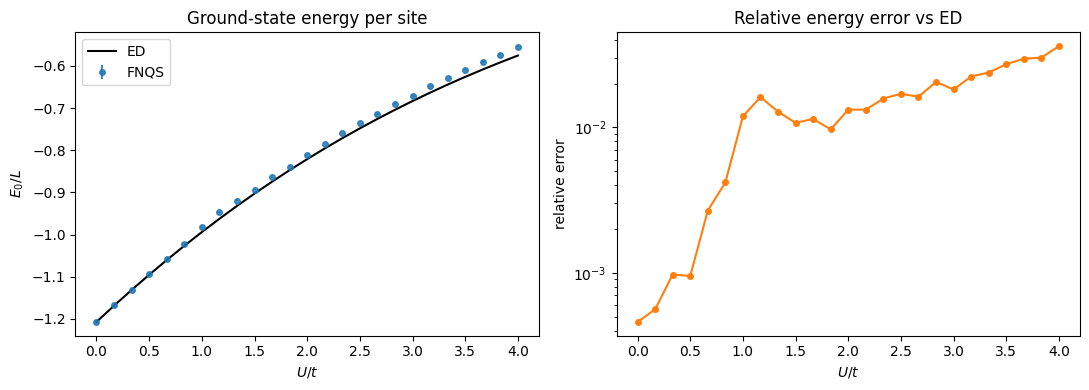

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: ground-state energy vs U
ax = axes[0]
ax.plot(U_sweep, ed_E / L, "k-", lw=1.5, label="ED")
ax.errorbar(
    U_sweep, vmc_E / L, yerr=vmc_E_err / L,
    fmt="o", ms=4, color="tab:blue", label="FNQS", alpha=0.85,
)
ax.set_xlabel("$U/t$")
ax.set_ylabel("$E_0 / L$")
ax.set_title("Ground-state energy per site")
ax.legend()

# Right: relative error vs U
ax = axes[1]
rel_err = np.abs((vmc_E - ed_E) / np.abs(ed_E))
ax.plot(U_sweep, rel_err, "-o", ms=4, color="tab:orange")
ax.set_xlabel("$U/t$")
ax.set_ylabel("relative error")
ax.set_title("Relative energy error vs ED")
ax.set_yscale("log")

plt.tight_layout()
plt.show()

## Quantum Fisher information via IS
---

The fidelity susceptibility with respect to $U$ is

$$
\chi(U) = \mathrm{Var}_{|\psi(U)|^2}\!\left[\partial_U \log\psi(\sigma;\,U)\right]
         = \bigl\langle (\partial_U \log\psi)^2\bigr\rangle
           - \bigl\langle \partial_U \log\psi\bigr\rangle^2.
$$

It measures how rapidly the ground-state manifold changes as $U$ is varied:
a large $\chi$ signals that the wavefunction is highly sensitive to the
interaction strength, which typically happens near crossover or transition
points.
We compute it via IS: reuse the nearest anchor state’s samples with IS weights,
then evaluate the weighted variance of $\partial_U\log\psi$ using `jax.jacfwd`.

In [7]:
U_anchors = np.linspace(0.25, 3.75, 6)
U_qfi     = np.linspace(0.0,  4.0,  41)

# Build anchor MCStates with more samples for reliable IS weights, thermalising
# each one (MCMC until R-hat < rhat_tol) before it is used as an IS reference.
anchor_states = {}
for U0 in U_anchors:
    mc = vs.get_state(jnp.array([float(U0)]))
    mc.n_samples = 2048
    mc.thermalise(create_operator(jnp.array([float(U0)])), rhat_tol=1.03, verbose=False)
    anchor_states[U0] = mc

def nearest_anchor(U):
    return U_anchors[np.argmin(np.abs(U_anchors - U))]

# IS sweep for chi(U)
qfi_vals = []
qfi_ess  = []

for U0 in U_qfi:
    mc_ref = anchor_states[nearest_anchor(U0)]
    pars   = jnp.array([float(U0)])
    is_st  = ISState.from_mc_state(mc_ref, pars)
    result = is_st.expect(SusceptibilityObservable(hi))
    qfi_vals.append(float(result.mean[0, 0]))
    qfi_ess.append(is_st.ess_fraction)

qfi_vals = np.array(qfi_vals)
qfi_ess  = np.array(qfi_ess)

print(f"QFI sweep done. Peak at U = {U_qfi[np.argmax(qfi_vals)]:.2f}")
print(f"Min ESS fraction: {qfi_ess.min():.2f}")

QFI sweep done. Peak at U = 1.20
Min ESS fraction: 0.13


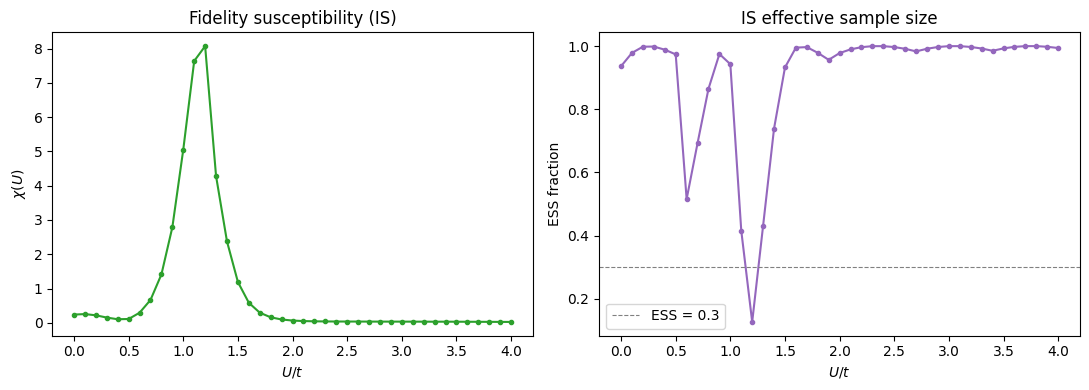

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(U_qfi, qfi_vals, "-o", ms=3, color="tab:green")
ax.set_xlabel("$U/t$")
ax.set_ylabel(r"$\chi(U)$")
ax.set_title("Fidelity susceptibility (IS)")

ax = axes[1]
ax.plot(U_qfi, qfi_ess, "-o", ms=3, color="tab:purple")
ax.axhline(0.3, ls="--", color="gray", lw=0.8, label="ESS = 0.3")
ax.set_xlabel("$U/t$")
ax.set_ylabel("ESS fraction")
ax.set_title("IS effective sample size")
ax.legend()

plt.tight_layout()
plt.show()